In [45]:
import wget
import healpy as hp
import numpy as np
import pylab as pl 
from pathlib import Path
import scipy
from scipy.odr import Model, Data, ODR
from scipy.optimize import curve_fit

from astropy import units as u, constants as const



def b(nu):
    """
    estimate dI/dT_CMB as defined in eq. 8 of Planck 2013 IX
    """
    nu0 = 56.8 * u.GHz
    x = nu / nu0
    Tcmb = 2.7255 * u.K
    bb = (
        2
        * const.h
        * nu ** 3
        / const.c ** 2
        / Tcmb
        * (x * np.exp(x) / (np.exp(x) - 1) ** 2)
    )
    return bb.to(u.W / u.m ** 2 / u.K / u.Hz)


def b_rj(nu):
    """
    estimate dI/dT_RJ as defined in eq. 30 of Planck 2013 IX
    """
    bb = 2 * const.k_B * nu ** 2 / const.c ** 2
    return bb.to(u.W / u.m ** 2 / u.K / u.Hz)

def brightness2Tcmb(nu, bandpass=None):
    """
    Convert from Jy/srad  to K_CMB
    """
    try:
        nu.unit
    except AttributeError:
        nu *= u.GHz

    if bandpass is None:
        integrand = b(nu)
        conversion_factor = 1 / integrand
    else:
        bandpass /= u.GHz
        integrand = b(nu) * bandpass
        conversion_factor = 1 / np.trapz(integrand, x=(nu))
    return conversion_factor


def brightness2Trj(nu, bandpass=None):
    """
    Convert from Jy/srad to K_RJ
    """
    try:
        nu.unit
    except AttributeError:
        nu *= u.GHz

    if bandpass is None:
        integrand = b_rj(nu)
        conversion_factor = 1 / integrand
    else:
        bandpass /= u.GHz
        integrand = b_rj(nu) * bandpass
        conversion_factor = 1 / np.trapz(integrand, x=(nu))
    return conversion_factor


def Krj2Kcmb(nu, Trj=1.0, bandpass=None):
    """
    Convert antenna temperature ( Rayleigh-Jeans) into the physical one
    """
    return Trj / Kcmb2Krj(
        nu=nu, Tcmb=1, bandpass=bandpass
    )  # (x ** 2 * np.exp(x) / (np.exp(x) - 1) ** 2)


def Kcmb2Krj(nu, Tcmb=1.0, bandpass=None):
    return (
        brightness2Trj(nu=nu, bandpass=bandpass)
        / brightness2Tcmb(nu=nu, bandpass=bandpass)
        * Tcmb
    )

def planckcorr(freq_ghz):
    """ Takes in frequency in GHZ and produces factor to be applied to temp """

    freq = freq_ghz * 10.**9.
    CST = {"kbolt": 1.3806488e-23, "light": 2.99792458e8, "plancks": 6.626e-34, "cmb_temp": 2.725}
    factor = CST["plancks"] * freq / (CST["kbolt"] * CST["cmb_temp"])
    correction = (np.exp(factor)-1.)**2. / (factor**2. * np.exp(factor))

    return correction



In [46]:
from scipy.odr import Model, Data, ODR
from scipy.stats import linregress

def rotate_map(mapin, coord_in , coord_out ) : 
    alm = hp.map2alm (mapin )
    R=  hp.Rotator(coord=[coord_in, coord_out ])
    alm =  R.rotate_alm (alm )
    map_out = hp.alm2map (alm , nside= hp.get_nside(mapin ))
    return map_out


def get_betas(xdat, xnoise, ydat, ynoise, v1, v2):
    """perform linear regression between two data set and get spectral index """

    mydata = Data(xdat, ydat, wd=xnoise**-2, we=ynoise**-2)
    myodr = ODR(mydata, Model(sform), beta0=[0.05, 0.5])
    myoutput = myodr.run()
    fitted_gradient = myoutput.beta[0]
    error_gradient = myoutput.sd_beta[0]

    ef = np.log(v2/v1)
    beta = np.log(fitted_gradient) / ef
    beta_error = error_gradient / (fitted_gradient * ef)
    
    return beta, beta_error, myoutput 
    
def sform(param, xxx):
    '''linear reggression'''
    return xxx * param[0] + param[1]

def fitting_beta_curvature(X, beta, cs):
   return beta*X +cs*X*X 

def sfunc(xxx, bval, cval):
    '''linear reggression'''
    return xxx * bval + cval

def remove_off(map, hasmap, maperr, haserr, nside_superpix=8):
    nside_superpix=16
    nan1 =np.ma.masked_invalid (map).mask 
    npix = map.size 
    pixs = np.arange(npix)
    try : 
        ang = hp.pix2ang(ipix= pixs[nan1][0] , nside= hp.get_nside(map)) 
        pix1 = hp.ang2pix(theta=ang[0] , phi = ang[1] , nside= nside_superpix)
    

        if pixs[nan1] [0]==0 :
            print("Southern Survey ") 
            super_pixs=  np.arange(pix1, hp.nside2npix(nside_superpix)) 
        else: 
            print("Northern survey ")
            super_pixs=  np.arange(pix1) 
    except IndexError: 
        print('Fullsky survey')
        super_pixs=  np.arange(hp.nside2npix(nside_superpix )) 
    offsets = np.zeros_like(super_pixs)*1. 
    nansize =0 
    for jj, ipix in enumerate(super_pixs) : 

        super_map = np.zeros(hp.nside2npix(nside_superpix))
        super_map [ipix] =1
        patch =  (hp.ud_grade(super_map, nside_out=hp.get_nside(map))) .astype('bool')
     
        try:
            
            errx = haserr[patch] * hasmap[patch]
            erry =  maperr * map[patch]
            mydata = Data(hasmap[patch], map[patch], wd=errx**-2, we=erry**-2)
            myodr = ODR(mydata, Model(sform), beta0=[0.0, 0.0])
            myoutput = myodr.run()
            cfit = myoutput.beta[1]

            if np.corrcoef(hasmap[patch].value, map[patch].value)[0,1] > 0.85:
                offsets[jj] = cfit
            else:
                offsets[jj] = np.nan
        except  ValueError: 
            nansize+=1 
            offsets[jj]= np.nan
            
    avec = np.nanmean( offsets ) *map.unit 
    map = map - avec
    
    return map, avec , np.nanstd(offsets) /np.sqrt(offsets.size - nansize)
 


https://lambda.gsfc.nasa.gov/product/wmap/dr5/ 

https://lambda.gsfc.nasa.gov/product/foreground/fg_all_sky150_mhzmap_get.html



https://lambda.gsfc.nasa.gov/data/map/dr5/skymaps/9yr/deconv/images/wmap_band_deconv_imap_r9_9yr_K_v5.fits

https://lambda.gsfc.nasa.gov/data/foregrounds/haslam_2014/haslam408_ds_Remazeilles2014.fits

https://lda10g.alliance.unm.edu/LWA1LowFrequencySkySurvey/
https://lambda.gsfc.nasa.gov/data/foregrounds/lwa1/healpix-all-sky-rav-wsclean-map-50.fits

https://lambda.gsfc.nasa.gov/product/foreground/fg_rhodes_hart_info.html


In [47]:
freqs=np.array([
    36.528, 41.760, 46.992, 52.224, 57.456, 62.688, 67.920, 73.152
    ]) 
maps={}
mapserr={}
offerr={}

cwd = Path.cwd() 
for j,fr in enumerate(freqs) :
    if fr == 41.76:
        fstring=(f"ovro_lwa_sky_map_41.760MHz.fits")
    elif fr == 67.92:
        fstring=(f"ovro_lwa_sky_map_67.920MHz.fits")
    else:
        fstring=(f"ovro_lwa_sky_map_{fr}MHz.fits")
    
    try : 
        print(f"reading {fstring} ")
        maps[fr],_=  hp.read_map(f"../lwa_data/{fstring}" ,h=True  )
    except FileNotFoundError: 
        filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/ovro/{fstring}", out ="../lwa_data")
        maps[fr]=  hp.read_map(f"../lwa_data/{fstring}"  )

    zeros = np.where(maps[fr] == 0.0)
    maps[fr][zeros] = np.nan 

    maps[fr]*=u.K
    mapserr[fr] = 0.05 # 5 per cent for LWA calibration 
    offerr[fr] = 0.0

nside = 512
npix = hp.nside2npix(nside)

reading ovro_lwa_sky_map_36.528MHz.fits 
reading ovro_lwa_sky_map_41.760MHz.fits 
reading ovro_lwa_sky_map_46.992MHz.fits 
reading ovro_lwa_sky_map_52.224MHz.fits 
reading ovro_lwa_sky_map_57.456MHz.fits 
reading ovro_lwa_sky_map_62.688MHz.fits 
reading ovro_lwa_sky_map_67.920MHz.fits 
reading ovro_lwa_sky_map_73.152MHz.fits 


In [48]:
freqs  =  np.array([  k for k in maps.keys()  ])  

fwhms = {36.528: 19.1*u.arcmin, 
         41.760: 17.5 *u.arcmin , 
        46.992: 16.3*u.arcmin,
        52.224: 15.2*u.arcmin,
        57.456: 14.9*u.arcmin,
        62.688: 15.0*u.arcmin,
        67.920: 15.0*u.arcmin,
        73.152: 15.1*u.arcmin,
        }

## smooth maps to 1.5 degrees
fwhmax = 20.*u.arcmin
# downgrade them to nside=512
print("smoothing and downgrading maps ")

for k  in freqs:
    nans= np.ma.masked_invalid(maps[k] ).mask
    maps[k] [nans] =hp.UNSEEN *maps[k].unit
    maps[k] = hp.smoothing(maps[k]  , fwhm=pl.sqrt(fwhmax**2 - fwhms[k] **2 ).to(u.rad).value  )*maps[k].unit
    if hp.get_nside(maps[k]) != nside  : 
        maps[k] = hp.ud_grade(maps[k].value , nside_out=nside)*maps[k].unit

    nans= np.ma.masked_equal(maps[k].value, hp.UNSEEN  ).mask
    maps[k][nans] = np.nan 

smoothing and downgrading maps 


## Offset removal 

In [49]:
from concurrent.futures import ThreadPoolExecutor
import tqdm

#read from fine_parameters.ipynb
offsets = np.array([-11201.5102, -8760.6860, -6618.3056, -4936.5284, -3813.4268, -2996.5210, -2532.9020, -1966.7192]) 
offserr = np.array([207.1281,  138.3796,  104.9595,  86.5059, 63.3790, 49.2977, 39.4927, 31.9153])
adder = 0

for k  in freqs:
    maps[k] = (maps[k].value - offsets[adder])*maps[k].unit
    adder += 1 

/var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_12338/2662058407.py:5: RuntimeWarning: invalid value encountered in log
  hp.mollview(np.log (m.value),  title=f'{fr} MHz'  , sub=(4,4,1+j) , notext=True)


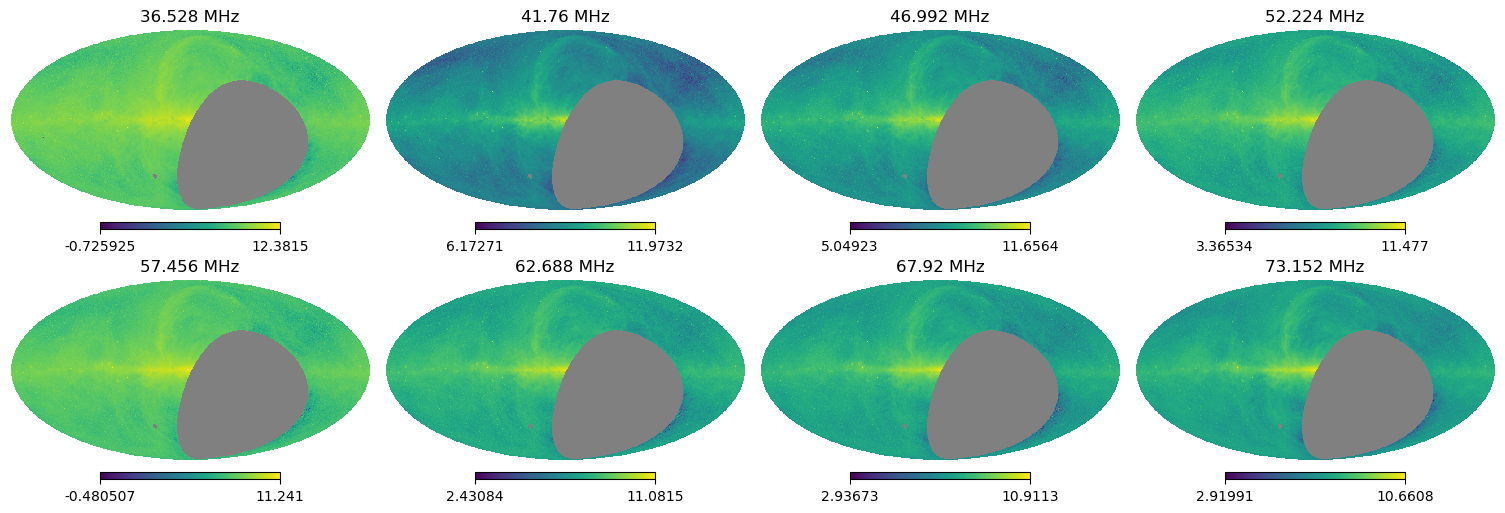

In [50]:
pl.figure(figsize=(15,10)) 
j=0
for fr,m in maps.items():
     
    hp.mollview(np.log (m.value),  title=f'{fr} MHz'  , sub=(4,4,1+j) , notext=True)
    
    j+=1


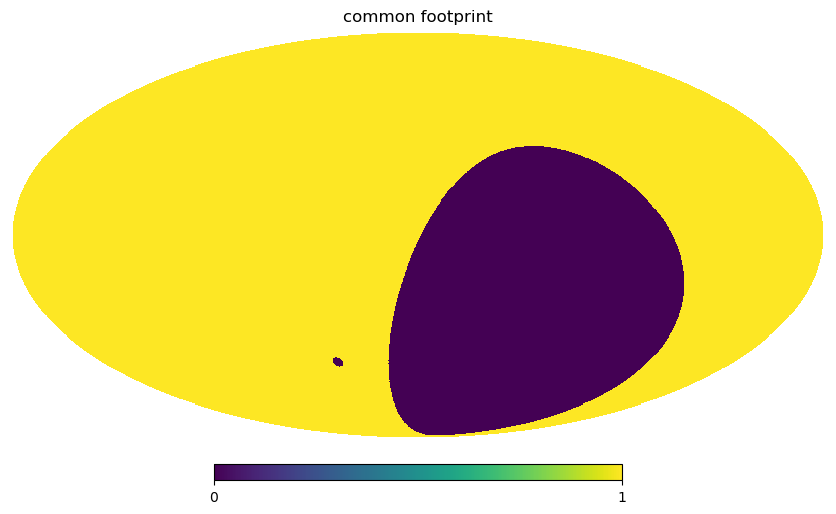

In [51]:
common_footprint =  ~np.ma.masked_invalid(maps[36.528] ).mask
hp.mollview(common_footprint, title='common footprint' )


In [52]:
fstring="COM_CompMap_freefree-commander_0256_R2.00.fits"
try :
    print(f"reading {fstring} ")
    tmp=  hp.read_map(filename=f"../lwa_data/{fstring}" ,field= ['EM_ML', 'TEMP_ML']  )  
except FileNotFoundError: 
    filename = wget.download( f"http://pla.esac.esa.int/pla/aio/product-action?MAP.MAP_ID=COM_CompMap_freefree-commander_0256_R2.00.fits" , out ="../lwa_data")
    tmp=  hp.read_map(f"../lwa_data/{fstring}" ,field= ['EM_ML', 'TEMP_ML']  )
 
planck_em = tmp[0]* u.cm**-6 *u.pc
planck_te = tmp [1]*u.K 

fstring = "EM_mean_std.fits"
try :
    print(f"reading {fstring} ")
    hust=  hp.read_map(filename=f"../lwa_data/{fstring}"   )  
except FileNotFoundError: 
    filename = wget.download( f"https://zenodo.org/records/10523170/files/EM_mean_std.fits" , out ="../lwa_data")
    hust =  hp.read_map(f"../lwa_data/{fstring}"    )
hust *= u.cm**-6 *u.pc

reading COM_CompMap_freefree-commander_0256_R2.00.fits 
reading EM_mean_std.fits 


In [53]:

Tff = lambda Te , nu,EM  : Te * (1.0 - np.exp(-tauff(Te,nu, EM ))) 
tauff = lambda Te,nu , EM : 0.05468 *   (Te.value )**-1.5 * (nu.value )**-2 *EM.value   *gff (Te,nu) 
Zi =1 
gff =lambda Te ,nu :  np.log (np.exp(1.0) +np.exp (5.960 -np.sqrt(3)/np.pi *np.log (Zi *nu.to(u.GHz).value *(Te/(1e4*u.K)  )**-1.5  )) )  

free ={} 
for fr in maps.keys() : 
    tmp = Tff(Te=planck_te, nu=(fr*u.MHz).to(u.GHz), EM=planck_em  )
    tmp = hp.ud_grade(tmp, nside_out=nside)
    print('FF Maps left at 1 degree res')
    #tmp = hp.smoothing(tmp, fwhm=pl.sqrt(fwhmax**2 -  1*u.deg **2 ).to(u.rad).value)
    free[fr]= (tmp)* (maps[36.528].unit)  

FF Maps left at 1 degree res
FF Maps left at 1 degree res
FF Maps left at 1 degree res
FF Maps left at 1 degree res
FF Maps left at 1 degree res
FF Maps left at 1 degree res
FF Maps left at 1 degree res
FF Maps left at 1 degree res


/var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_12338/4080078815.py:5: RuntimeWarning: invalid value encountered in log10
  hp.mollview(  pl.log10((m .value  -free[fr ].value  )  )   ,  title=f'{fr} MHz'  , sub=(4,4,1+j) , notext=True)


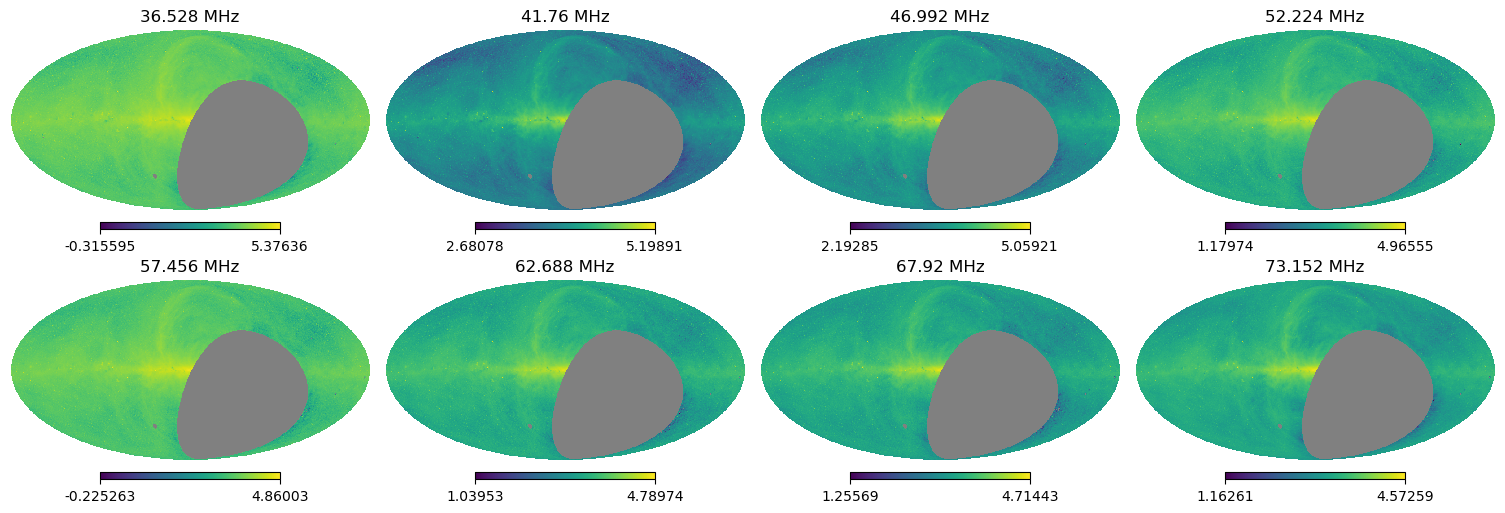

In [54]:
pl.figure(figsize=(15,10)) 
j=0
for fr,m in maps.items():
     
    hp.mollview(  pl.log10((m .value  -free[fr ].value  )  )   ,  title=f'{fr} MHz'  , sub=(4,4,1+j) , notext=True)
    
    j+=1

pl.show() 

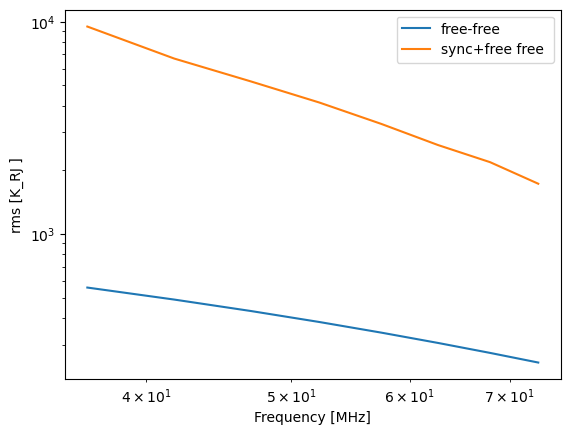

In [55]:
rmsf =np.array( [ np.nanstd(f .value)    for f in free.values() ] ) 
rmsm = np.array( [ np.nanstd(m .value)    for m in maps.values() ] ) 
pl.loglog( freqs, rmsf  ,label='free-free' ,)
pl.loglog( freqs, rmsm  , label='sync+free free ', )

pl.legend()
pl.xlabel('Frequency [MHz]')
pl.ylabel('rms [K_RJ ]')  
pl.show() 


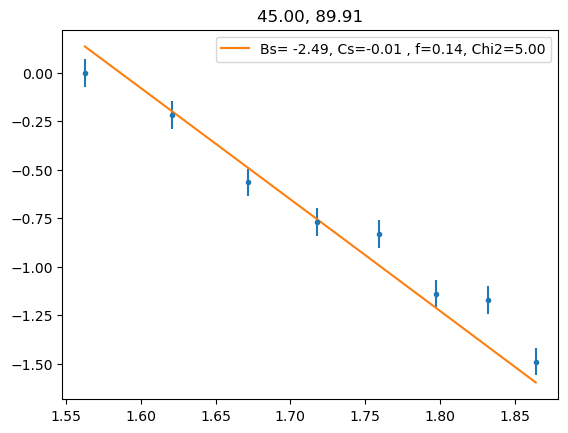

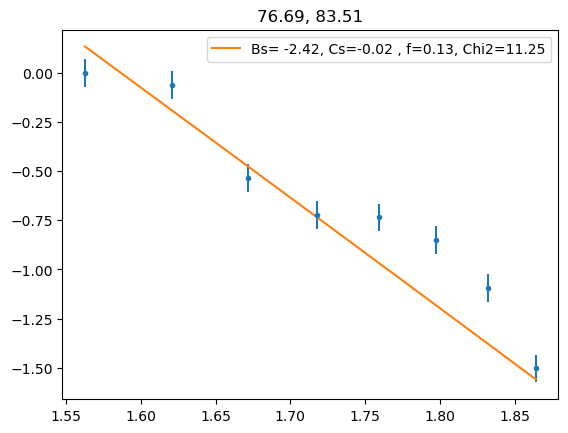

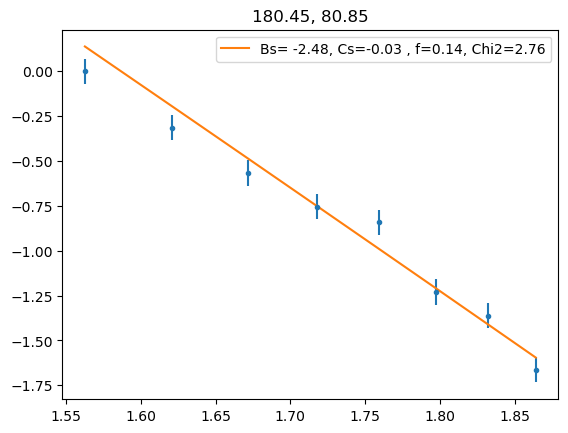

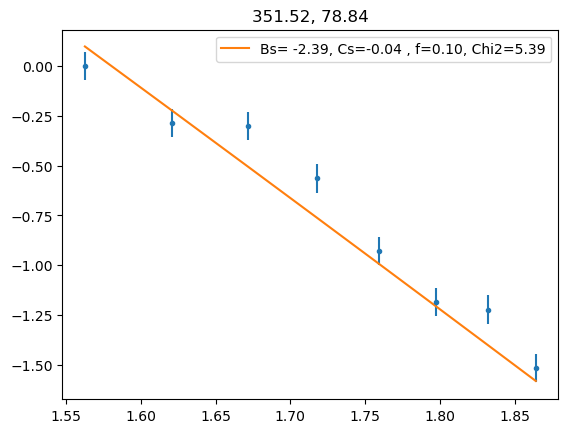

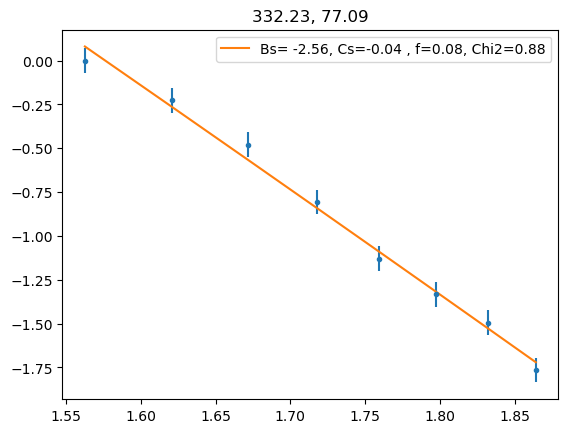

In [56]:
oldbs = np.load('beta_90arcmin.npy')
oldcs = np.load('cs_90arcmin.npy')
olda = np.load('amp_90arcmin.npy')


def fitting_beta_curvature(X, beta, cs, const):
   return beta*X +cs*X*X + const
def process_pixel(ipix):
    ifreq= np.argmin(np.abs(freqs - 36.528))
    pixvals = np.array([ (m[ipix].value - free[k][ipix ] .value)  for k, m in maps.items() ])
    nans = np.isnan(pixvals)
    ydat = pl.log(pixvals / pixvals[ifreq])
    xdat = pl.log(freqs / freqs[ifreq] )

    #data errors are calibration errors plus offset errors
    pix_errs = np.zeros_like(ydat)
    cc = 0
    for k, m in maps.items():
        errm = mapserr[k]
        if isinstance(errm, np.ndarray):
            vals = mapserr[k]
            errm = vals[ipix].value
        pix_errs[cc] = np.sqrt((errm * m[ipix].value)**2 + offerr[k]**2)
        cc += 1
    logyerr = np.sqrt((pix_errs[0] /pixvals[0])**2 + (pix_errs / pixvals)**2)

    ret = np.full(5, np.nan )
    ret[0] = ipix
    pcov = np.zeros((3, 3)) + np.nan
    if nans.sum():
        return ret, pcov 
    try:
        p0 = np.array([oldbs[ipix], 
                   oldcs[ipix],
                  olda[ipix] ,
                    ])
        lowb = oldbs[ipix] - 0.05 * abs(oldbs[ipix])
        hib = oldbs[ipix] + 0.05 * abs(oldbs[ipix])
        lowc = oldcs[ipix] - 0.05 *abs(oldcs[ipix])
        hic = oldcs[ipix] + 0.05 * abs(oldcs[ipix])
        lowa = olda[ipix] - 0.05 * abs(olda[ipix])
        hia = olda[ipix] + 0.05 * abs(olda[ipix])
        popt, pcov = curve_fit(fitting_beta_curvature, xdat, ydat, 
                               sigma=logyerr,  p0=p0, bounds = ((lowb, lowc, lowa), (hib, hic, hia))) 
        ret[-1] = np.sum(((ydat - fitting_beta_curvature(xdat, *popt)) / logyerr) ** 2)/(xdat.size -p0.size   )
        ret [1:-1] = popt 
        return ret, pcov 
    except :
        return ret, pcov 

pixel_select= np.arange ( npix )[common_footprint ]
 
ifreq= np.argmin(np.abs(freqs - 36.528))

xdat =   pl.log(freqs  /freqs[ifreq]) 
betamap = np.full(hp.nside2npix(nside ), np.nan)
fmap=  np.full(hp.nside2npix(nside ), np.nan)
csmap = np.full(hp.nside2npix(nside ), np.nan)
betafmap = np.full(hp.nside2npix(nside), np.nan)
chisquare_map = np.full(hp.nside2npix(nside), np.nan)
#variables b, c, const
bb_mat = np.full(hp.nside2npix(nside), np.nan)
bc_mat = np.full(hp.nside2npix(nside), np.nan)
bconst_mat = np.full(hp.nside2npix(nside), np.nan)
cc_mat = np.full(hp.nside2npix(nside), np.nan)
cconst_mat = np.full(hp.nside2npix(nside), np.nan)
constconst_mat = np.full(hp.nside2npix(nside), np.nan)

jj=0 
for ipix  in pixel_select[::1000]:

    fitted_params, pcov = process_pixel(ipix)
    #  beta, cs, constant

    bb_mat[ipix] = pcov[0,0]
    bc_mat[ipix] = pcov[0,1]
    bconst_mat[ipix] = pcov[0,2]
    cc_mat[ipix] = pcov[1,1]
    cconst_mat[ipix] = pcov[1,2]
    constconst_mat[ipix] = pcov[2,2] 

    betamap[ipix] = fitted_params[1]
    fmap[ipix] =   fitted_params[3]
    #betafmap[ipix] = fitted_params[4]

    csmap[ipix] = fitted_params[2]
    chisquare_map[ipix] = fitted_params[-1]

    ifreq= np.argmin(np.abs(freqs - 36.528))
    pixvals = np.array([ (m[ipix].value - free[k][ipix ] .value)  for k, m in maps.items() ])
    nans = np.isnan(pixvals)
    ydat = pl.log(pixvals / pixvals[ifreq])
    xdat = pl.log(freqs / freqs[ifreq] )

    #data errors are calibration errors plus offset errors
    pix_errs = np.zeros_like(ydat)
    cc = 0
    for k, m in maps.items():
        errm = mapserr[k]
        if isinstance(errm, np.ndarray):
            vals = mapserr[k]
            errm = vals[ipix].value
        pix_errs[cc] = np.sqrt((errm * m[ipix].value)**2 + offerr[k]**2)
        cc += 1
    logyerr = np.sqrt((pix_errs[0] /pixvals[0])**2 + (pix_errs / pixvals)**2)

    if jj%10==0:
        pl.figure() 
        lon,lat =hp.pix2ang(ipix=ipix, nside=hp.get_nside(maps[36.528]), lonlat=True) 
        pl.title( f"{lon:.2f}, {lat:.2f}" )
        pl.errorbar ( pl.log10(freqs) ,  ydat ,
                     yerr= logyerr  ,
                        fmt='.' )
         
        pl.plot( pl.log10(freqs) ,  fitting_beta_curvature( xdat , *fitted_params[1:-1] ),  
                label =f'Bs= {fitted_params[1]:.2f}, Cs={fitted_params[2]:.2f} , f={fitted_params[3]:.2f}, Chi2={fitted_params[-1]:.2f}' ) 
                #, Bf={fitted_params[4]:.2f}, 

        #pl.semilogx() 
        #pl.loglog() 
        pl.legend() 
    jj+=1 
    if jj== 50: break
    #break 
pl.show() 

In [57]:
from concurrent.futures import ThreadPoolExecutor
import tqdm

    
# Initialize shared arrays
betamap = np.full(hp.nside2npix(nside), np.nan)
fmap = np.full(hp.nside2npix(nside), np.nan)
csmap = np.full(hp.nside2npix(nside), np.nan)
betafmap = np.full(hp.nside2npix(nside), np.nan)
chisquare_map = np.full(hp.nside2npix(nside), np.nan)

bb_mat = np.full(hp.nside2npix(nside), np.nan)
bc_mat = np.full(hp.nside2npix(nside), np.nan)
bconst_mat = np.full(hp.nside2npix(nside), np.nan)
cc_mat = np.full(hp.nside2npix(nside), np.nan)
cconst_mat = np.full(hp.nside2npix(nside), np.nan)
constconst_mat = np.full(hp.nside2npix(nside), np.nan)


# Use ThreadPoolExecutor for parallel processing
with ThreadPoolExecutor() as executor:
    results = list(tqdm.tqdm(executor.map(process_pixel, pixel_select), total=len(pixel_select)))

for fitted_params, pcovs in results:
    ipix = int(fitted_params[0])  # Ensure ipix is an integer
    betamap[ipix] = fitted_params[1]
    csmap[ipix] = fitted_params[2]
    fmap[ipix] =   fitted_params[3]
    #betafmap[ipix] = fitted_params[4]

    chisquare_map[ipix] = fitted_params[-1]

    bb_mat[ipix] = pcovs[0,0]
    bc_mat[ipix] = pcovs[0,1]
    bconst_mat[ipix] = pcovs[0,2]
    cc_mat[ipix] = pcovs[1,1]
    cconst_mat[ipix] = pcovs[1,2]
    constconst_mat[ipix] = pcovs[2,2] 

/var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_12338/207864630.py:12: RuntimeWarning: invalid value encountered in log
  ydat = pl.log(pixvals / pixvals[ifreq])
/var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_12338/207864630.py:43: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(fitting_beta_curvature, xdat, ydat,
100%|██████████| 2359675/2359675 [00:15<00:00, 150508.64it/s]


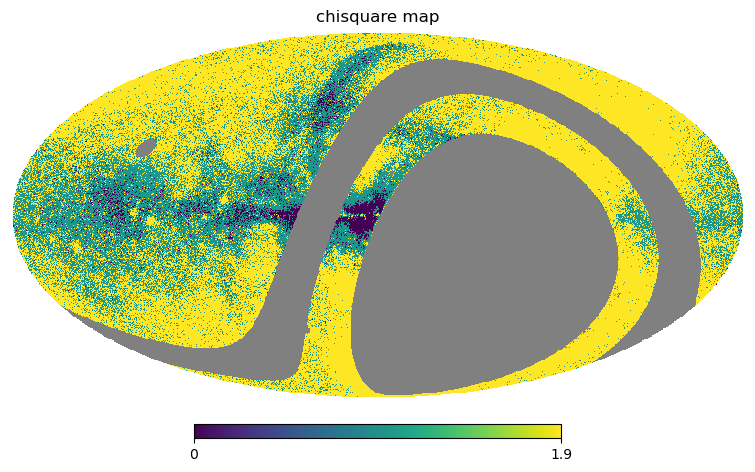

In [58]:
clust = np.ones_like (chisquare_map) 

mask  = np.ma.masked_inside (chisquare_map , 0.5,2).mask
clust[mask] = 1
clust[~mask] = 0
mask =np.ma.masked_inside (chisquare_map , 2,5).mask
clust[mask] = 2 
mask =np.ma.masked_greater(chisquare_map , 5).mask
clust[mask] = 3
clust[np.ma.masked_invalid(chisquare_map).mask] = np.nan 
pl.figure(figsize=(15,10))
hp.mollview(clust, title='chisquare map', sub=(2,2,1),   notext=True, min=0, max=1.9)
pl.show() 


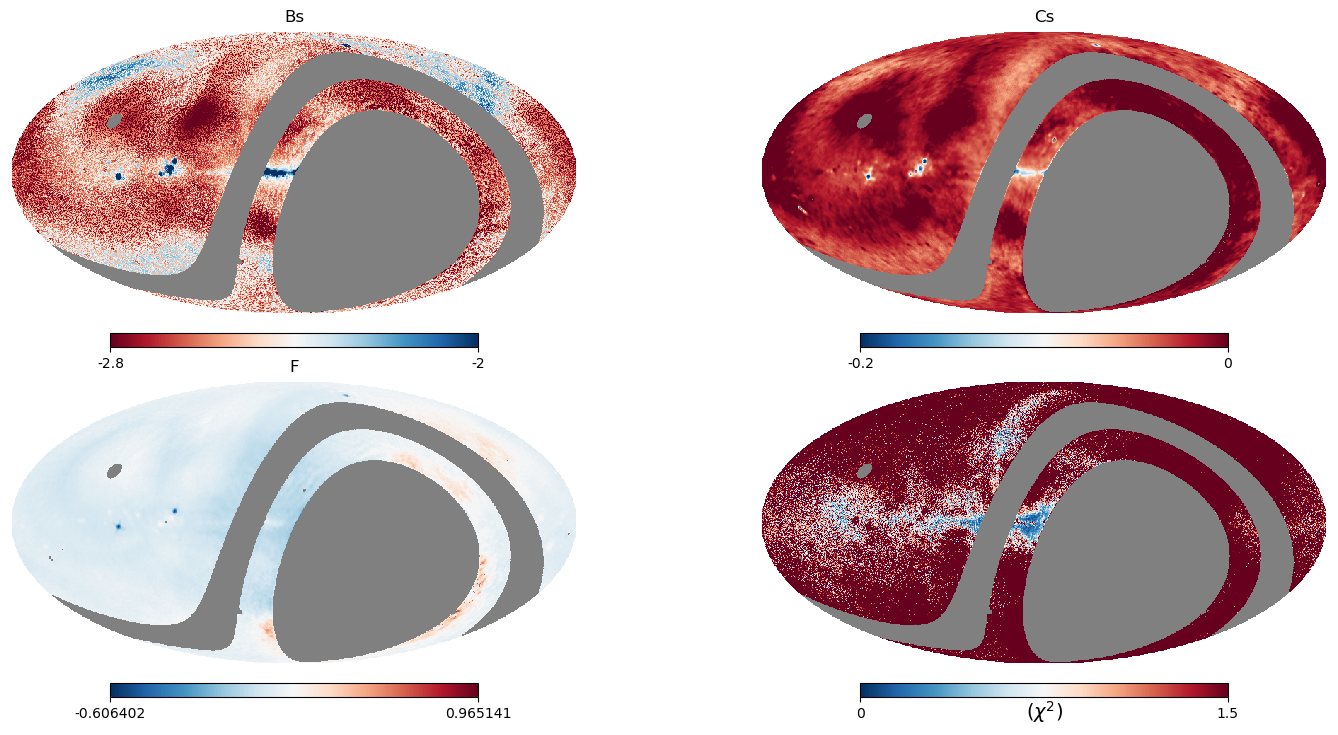

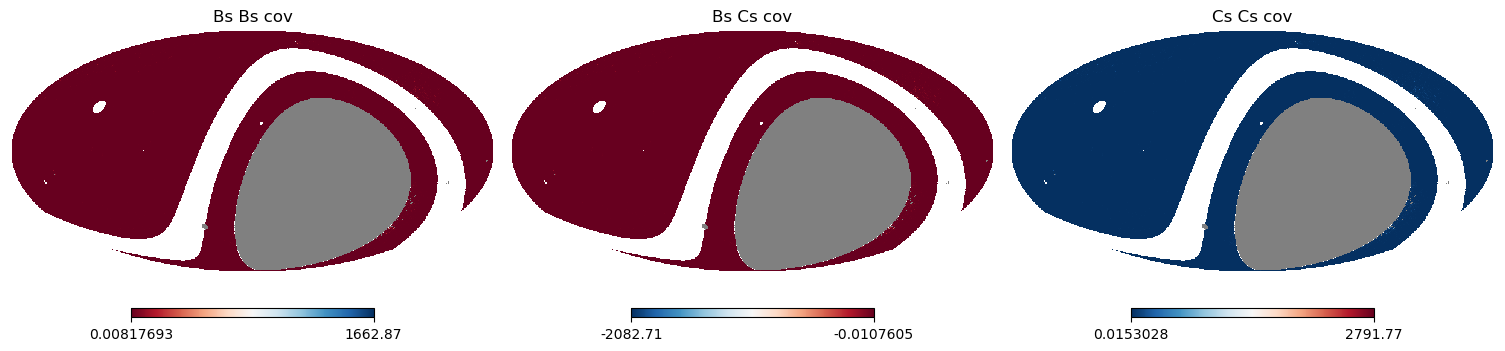

In [59]:
pl.figure(figsize=(15,7 ))
hp.mollview(betamap , sub=221 , min=-2.8,max=- 2., title ='Bs',cmap='RdBu', notext=True) 
hp.mollview(csmap , sub=222, min=-0.2,max=0. ,title='Cs',cmap='RdBu_r', notext=True) 
hp.mollview(fmap  , sub=223,   title='F',cmap='RdBu_r', notext=True) 
hp.mollview(chisquare_map   , sub=224,  min=0 ,max=1.5,    unit=r'$ (\chi^2)$',cmap='RdBu_r',notext=True , title=' ' ) 
pl.show()

pl.figure(figsize=(15,7 ))
hp.mollview(bb_mat, sub=131 , title ='Bs Bs cov',cmap='RdBu',notext=True) 
hp.mollview(bc_mat , sub=132, title='Bs Cs cov',cmap='RdBu_r', notext=True) 
hp.mollview(cc_mat  , sub=133,   title='Cs Cs cov',cmap='RdBu_r', notext=True) 
pl.show()


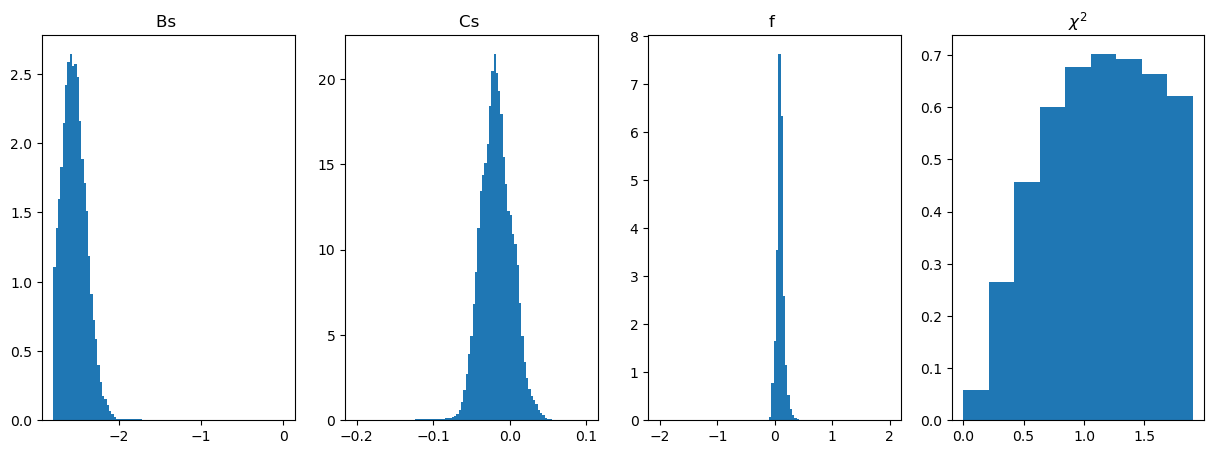

In [60]:
pl.figure(figsize=(15,5))
pl.subplot(141) 
pl.title ('Bs ')
cb= pl.hist(betamap, bins=np.linspace(-2.8, -0, 100), density=True ) 
pl.subplot(142) 
pl.title ('Cs ')
cc= pl.hist(csmap, bins=np.linspace(-.2,  .1, 100), density=True  )
#pl.subplot(153) 
#pl.title ('Bf ')
#pl.hist(betafmap, bins=np.linspace(-3 , 2.0, 100), density=True  )

pl.subplot(143) 
pl.title ('f ') 
pl.hist(fmap, bins=np.linspace(-2, 2.0, 100), density=True  )
pl.subplot(144)
pl.title (r'$\chi^2$') 
_=pl.hist(chisquare_map, bins=np.linspace(0, 1.9, 10), density=True  )
pl.show() 


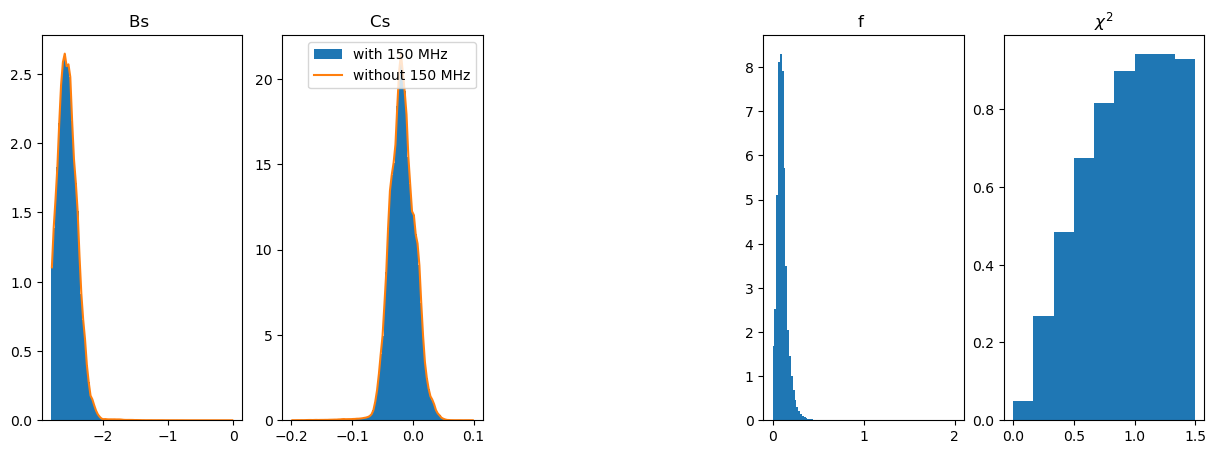

In [61]:
pl.figure(figsize=(15,5))
pl.subplot(151) 
pl.title ('Bs ')
pl.hist(betamap, bins=np.linspace(-2.8, -0, 100), density=True ) 
bins = [(cb[1][i] + cb[1][i+1] ) / 2 for i in range(len(cb[1])-1)]
pl.plot (bins, cb[0] )
pl.subplot(152) 
pl.title ('Cs ')
pl.hist(csmap, bins=np.linspace(-.2,  .1, 100), density=True, label='with 150 MHz')
bins = [(cc[1][i] + cc[1][i+1] ) / 2 for i in range(len(cc[1])-1)]
pl.plot (bins, cc[0] , label = 'without 150 MHz')
#pl.subplot(153) 
#pl.title ('Bf ')
#pl.hist(betafmap, bins=np.linspace(-3 , 2.0, 100), density=True  )
pl.legend() 
pl.subplot(154) 
pl.title ('f ') 
pl.hist(fmap, bins=np.linspace(0, 2.0, 100), density=True  )
pl.subplot(155)
pl.title (r'$\chi^2$') 
_=pl.hist(chisquare_map, bins=np.linspace(0, 1.5, 10), density=True  )
pl.show() 


## Fitting linear 

In [ ]:

def fitting_sync_ff(X,  beta, cs,facta): 
                    #, betaf ):
   return ( facta * X**(beta + cs * np.log(X) )  ) 
            #+ (1 - facta) * X**(betaf)) 
def fitting_beta_curvature(X, beta, cs, const):
   return beta*X +cs*X*X + const
def process_pixel(ipix):
    ifreq= np.argmin(np.abs(freqs - 36.528))
    pixvals = np.array([ (m[ipix].value - free[k][ipix ] .value)  for k, m in maps.items() ])
    nans = np.isnan(pixvals)
    ydat = (pixvals / pixvals[ifreq])
    xdat = (freqs / freqs[ifreq] )

    #data errors are calibration errors plus offset errors
    pix_errs = np.zeros_like(ydat)
    cc = 0
    for k, m in maps.items():
        errm = mapserr[k]
        if isinstance(errm, np.ndarray):
            vals = mapserr[k]
            errm = vals[ipix].value
        pix_errs[cc] = np.sqrt((errm * m[ipix].value)**2 + offerr[k]**2)
        cc += 1
    yerr = abs(pixvals) * np.sqrt((pix_errs[0] /pixvals[0])**2 + (pix_errs / pixvals)**2)
    
    p0 = np.array([-3, 
                   -0.1,
                  1 ,
                  #-2.13, 
                    ])
    ret = np.full( p0.size +2 , np.nan )
    ret[0] = ipix 
    if nans.sum():
        return ret 
    try:
        popt, pcov = curve_fit(fitting_sync_ff, xdat, ydat, 
                               sigma=yerr,  p0=p0    ) 
                               #bounds=[(-3.8, -0.5, 0), (-2.0, 0.0, 1)])
        ret[-1] = np.sum(((ydat - fitting_sync_ff(xdat, *popt)) / yerr) ** 2)/(xdat.size -p0.size   )
        ret [1:-1] = popt 
        return ret 
    except :
        return ret 
    


pixel_select= np.arange ( npix )[common_footprint ]
 
ifreq= np.argmin(np.abs(freqs - 36.528))

xdat =   (freqs  /freqs[ifreq]) 
betamap = np.full(hp.nside2npix(nside ), np.nan)
fmap=  np.full(hp.nside2npix(nside ), np.nan)
csmap = np.full(hp.nside2npix(nside ), np.nan)
betafmap = np.full(hp.nside2npix(nside), np.nan)
chisquare_map = np.full(hp.nside2npix(nside), np.nan)
jj=0 
for ipix  in pixel_select[::1000]:
    pixvals = np.array([(m[ipix].value - free[k][ipix ] .value  ) for k, m in maps.items()])
   

    ydat = ( pixvals / pixvals[ifreq])

    yerr = np.full_like(ydat, np.sqrt(2) * .1)* np.fabs(ydat) 
 
    #logyerr = np.full_like(ydat, np.sqrt(2) * 0.15) 
    fitted_params =process_pixel(ipix)
    #  beta, cs,facta, betaf

    betamap[ipix] = fitted_params[1]
    fmap[ipix] =   fitted_params[3]
    #betafmap[ipix] = fitted_params[4]

    csmap[ipix] = fitted_params[2]
    chisquare_map[ipix] = fitted_params[-1]

    if jj%10==0:
        pl.figure() 
        lon,lat =hp.pix2ang(ipix=ipix, nside=hp.get_nside(maps[36.528]), lonlat=True) 
        pl.title( f"{lon:.2f}, {lat:.2f}" )
        pl.errorbar ( freqs ,  ydat ,
                     yerr= yerr  ,
                        fmt='.' )
         
        pl.plot( freqs ,  fitting_sync_ff( xdat , *fitted_params[1:-1] ),  
                label =f'Bs= {fitted_params[1]:.2f}, Cs={fitted_params[2]:.2f} , f={fitted_params[3]:.2f}, Chi2={fitted_params[-1]:.2f}' ) 
                #, Bf={fitted_params[4]:.2f}, 

        #pl.semilogx() 
        pl.loglog() 
        pl.legend() 
    jj+=1 
    if jj== 50: break
    #break 
pl.show() 